In [23]:
import numpy as np
import matplotlib.pyplot as plt

In [24]:
time_step        = 1/16
state_action_step = 1/8

time = np.arange(0, 1.0, time_step, dtype=float)
n_time_steps = len(time)
T  = n_time_steps

state_space = np.arange(-1.5, 2.00, state_action_step, dtype=float)  
action_space = np.arange(-2.5, 1.25, state_action_step, dtype=float)  

n_states = len(state_space)
n_actions = len(action_space)

print(f"States  ({n_states}):",  state_space)
print(f"Actions ({n_actions}):", action_space)
print(time)

c_alpha  = 1
x_state  = 2
gamma = 1.75
c_g = 0.3
x_vol = 0.5
sigma_0 = 0.5
dt = time_step


phi = 15      
om_q  = 0.55   
om_mu = 0.85   
tol   = 0.1    

States  (14): [-1.5  -1.25 -1.   -0.75 -0.5  -0.25  0.    0.25  0.5   0.75  1.    1.25
  1.5   1.75]
Actions (15): [-2.5  -2.25 -2.   -1.75 -1.5  -1.25 -1.   -0.75 -0.5  -0.25  0.    0.25
  0.5   0.75  1.  ]
[0.     0.0625 0.125  0.1875 0.25   0.3125 0.375  0.4375 0.5    0.5625
 0.625  0.6875 0.75   0.8125 0.875  0.9375]


In [25]:
def state_discretize(x):
    """Map continuous x to nearest state index."""
    idx = np.argmin(np.abs(state_space - x))
    return int(np.clip(idx, 0, n_states - 1))

def c_a(alpha):
    return 0.5 * c_alpha * np.power(alpha, 2)

def c_x_func(x):
    return 0.5 * x_state * np.power(x, 2)

def get_mean_action(mu, t_idx):
    return np.dot(mu[t_idx], action_space[:n_states]) 

def immediate_costs(x_val, alpha_val, t_idx, mu):

    nu = 0.0  
    cost = (c_a(alpha_val) + c_x_func(x_val)) - gamma * x_val * nu
    return cost * dt

def immediate_costs_with_nu(x_val, alpha_val, nu):
    """f(x, a, nu) * dt  — explicit nu version used inside T_2."""
    cost = (c_a(alpha_val) + c_x_func(x_val)) - gamma * x_val * nu
    return cost * dt

def trans_kernel_prob(x_idx, a_idx, xp_idx, nu, n_samples=500):
    x     = state_space[x_idx]
    alpha = action_space[a_idx]
    count = 0
    for _ in range(n_samples):
        noise  = x_vol * np.sqrt(dt) * np.random.randn()
        x_next = x + alpha * dt + noise
        if state_discretize(x_next) == xp_idx:
            count += 1
    return count / n_samples

def trans_kernel_row(x_idx, a_idx, nu, n_samples=500):
    x  = state_space[x_idx]
    alpha = action_space[a_idx]
    counts = np.zeros(n_states)
    noise  = x_vol * np.sqrt(dt) * np.random.randn(n_samples)
    x_nexts = x + alpha * dt + noise
    for xn in x_nexts:
        counts[state_discretize(xn)] += 1
    return counts / n_samples  

In [26]:
def soft_min(q_row):
 
    shifted = -phi * (q_row - np.min(q_row))
    return np.min(q_row) - (1.0 / phi) * np.log(np.sum(np.exp(shifted)))

def soft_min_action_idx(q_row):
 
    logits = -phi * (q_row - np.min(q_row))
    probs  = np.exp(logits) / np.sum(np.exp(logits))
    return np.random.choice(n_actions, p=probs)


def T_2(Q, mu, x_idx, a_idx, t):

    # Mean-field scalar: nu = sum_x mu_t(x) * soft-min action value at x\
    for xi in range(n_states):
        nu = np.sum(mu[t][xi] * action_space[soft_min_action_idx(Q[t][xi])])
       

    x_val = state_space[x_idx]
    alpha_val = action_space[a_idx]
    cost = immediate_costs_with_nu(x_val, alpha_val, nu)

    # Future value: sum_{x'} p(x'|x,a) * min_{a'} Q_{t+1}(x', a')
    if t == T - 1:
        future_val = 0.0   
    else:
        p_row = trans_kernel_row(x_idx, a_idx, nu)   # shape (n_states,)
        min_q_next = np.array([np.min(Q[t + 1][xp]) for xp in range(n_states)])
        future_val = np.dot(p_row, min_q_next)

    return cost + future_val - Q[t][x_idx][a_idx]


def P_V2_MFG(Q, mu, t):
    """
    P_2(Q, mu)(x) = sum_{x'} mu_t(x') * p(x | x', soft-min_phi Q_t(x'), mu) - mu_t(x)

    Returns delta vector of shape (n_states,).
    mu[t] has shape (n_states,) — distribution over states at time t.
    """
    # Mean-field scalar nu (same as in T_2)
    nu = sum(
        mu[t][xi] * action_space[soft_min_action_idx(Q[t][xi])]
        for xi in range(n_states)
    )

    result = np.zeros(n_states, dtype=float)

    for xp_idx in range(n_states):
        if mu[t][xp_idx] == 0.0:
            continue
        a_soft_idx = soft_min_action_idx(Q[t][xp_idx])
        # Transition distribution p(x | x', a_soft, nu)
        p_row = trans_kernel_row(xp_idx, a_soft_idx, nu) 
        result += mu[t][xp_idx] * p_row

    result -= mu[t] 
    return result    

In [27]:

Q = np.full((T, n_states, n_actions), 30.0, dtype=float)

mu = np.ones((T, n_states), dtype=float)
for t in range(T):
    mu[t] /= np.sum(mu[t]) 

print("Q shape:", Q.shape)
print("mu shape:", mu.shape)

Q shape: (16, 14, 15)
mu shape: (16, 14)


In [28]:


SSE_history = []

for k in range(10000):
    SSE = 0.0

    rho_mu = 1.0 / np.power(1 + k, om_mu) 
    rho_q  = 1.0 / np.power(1 + k, om_q)


    mu_deltas = np.zeros_like(mu) 
    Q_deltas  = np.zeros_like(Q)    

    for t in range(T):
        mu_deltas[t] = P_V2_MFG(Q, mu, t)

        for x in range(n_states):
            for a in range(n_actions):
                Q_deltas[t][x][a] = T_2(Q, mu, x, a, t)


    for t in range(T):
        mu[t] += rho_mu * mu_deltas[t]
        mu[t] = project_simplex(mu[t])   
        SSE   += np.sum((rho_mu * mu_deltas[t]) ** 2)

        for x in range(n_states):
            for a in range(n_actions):
                step         = rho_q * Q_deltas[t][x][a]
                Q[t][x][a] += step
                SSE         += step ** 2

    SSE_history.append(SSE)
    print("%4d  SSE=%12.6f  rho_mu=%.5f  rho_q=%.5f" % (k, SSE, rho_mu, rho_q))

    if SSE < tol:
        print(f"Converged at iteration {k}")
        break

   0  SSE=187546.031144  rho_mu=1.00000  rho_q=1.00000
   1  SSE=87827.468420  rho_mu=0.55478  rho_q=0.68302
   2  SSE=31824.178512  rho_mu=0.39305  rho_q=0.54649
   3  SSE=16059.051569  rho_mu=0.30779  rho_q=0.46652
   4  SSE=10267.423859  rho_mu=0.25461  rho_q=0.41264
   5  SSE= 7317.897407  rho_mu=0.21806  rho_q=0.37326
   6  SSE= 5563.921970  rho_mu=0.19128  rho_q=0.34292
   7  SSE= 4419.921328  rho_mu=0.17076  rho_q=0.31864
   8  SSE= 3624.582013  rho_mu=0.15449  rho_q=0.29865
   9  SSE= 3043.580102  rho_mu=0.14125  rho_q=0.28184
  10  SSE= 2605.395430  rho_mu=0.13026  rho_q=0.26744
  11  SSE= 2264.064337  rho_mu=0.12098  rho_q=0.25495
  12  SSE= 1992.061215  rho_mu=0.11302  rho_q=0.24397
  13  SSE= 1771.274232  rho_mu=0.10612  rho_q=0.23422
  14  SSE= 1589.048634  rho_mu=0.10007  rho_q=0.22550
  15  SSE= 1436.751757  rho_mu=0.09473  rho_q=0.21764
  16  SSE= 1307.208306  rho_mu=0.08997  rho_q=0.21050
  17  SSE= 1196.875451  rho_mu=0.08571  rho_q=0.20399
  18  SSE= 1101.191619  rho

KeyboardInterrupt: 

## Convergence Plot

/var/folders/qc/3k0cg2ln303fqtd_5xb424mw0000gn/T/ipykernel_1619/265006865.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


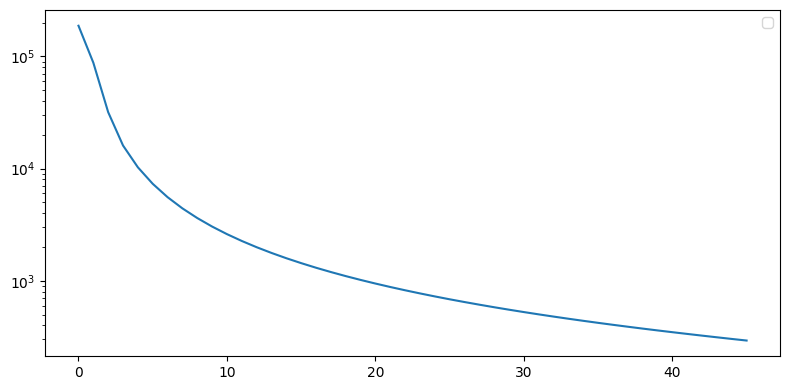

In [29]:
plt.figure(figsize=(8, 4))
plt.semilogy(SSE_history)
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
print(mu[0])
print(mu[7])
print(mu[15])

print(np.mean(mu[0]))
print(np.mean(mu[7]))
print(np.mean(mu[15]))

[0.08252883 0.07429902 0.07377739 0.07687226 0.07798399 0.07672334
 0.06956917 0.07732873 0.08273811 0.07257993 0.06992387 0.07415695
 0.05442945 0.03708897]
[0.0965478  0.07707828 0.0739023  0.07334325 0.07810933 0.08827443
 0.074639   0.06752649 0.06666287 0.064481   0.06672381 0.06622687
 0.06145118 0.04503336]
[0.10166977 0.07731245 0.07293703 0.06536593 0.06733881 0.06955213
 0.06833235 0.06920881 0.07212972 0.07502602 0.0884754  0.0847092
 0.05601286 0.03192951]
0.07142857142857142
0.07142857142857142
0.07142857142857147
